In [1]:
import pandas as pd
import cobra
# import memote
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm


In [2]:
df = pd.read_excel('./../autopacmen_output/autopacmen_metrics.xlsx')

In [3]:
df = df.transpose()
df = df.rename(columns=df.iloc[0]).drop(df.index[0])
df

,Preliminary,MitoMammal,aligned to Human1
mapped proteins,228,228,296
retrieved kcat values,295,298,309
reactions with protein constraints,168,170,202


C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_20504\4268416432.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu", len(models) + 1)


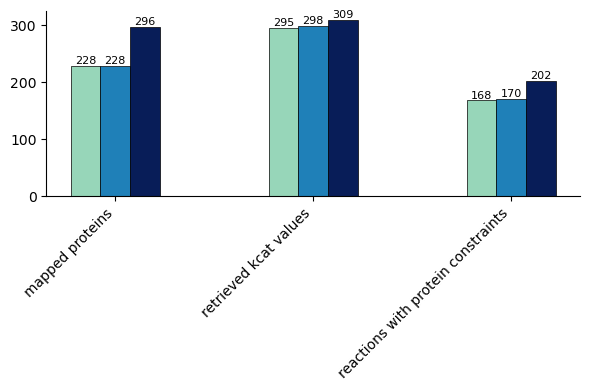

In [4]:
# 1. Split your metrics
all_metrics = df.index
models = df.columns
# 2. Setup Figure with two subplots (Adjust width_ratios as needed)
fig, ax = plt.subplots(figsize=(6, 4))

cmap = cm.get_cmap("YlGnBu", len(models) + 1)
colors = [cmap(i) for i in range(1, len(models) + 1)]
width = 0.15

# Helper function to avoid repeating the bar logic
def draw_bars(ax, metrics, offset, rotation=90, y_lim=None):
    x = np.arange(len(metrics))
    data = df.loc[metrics]
    
    for i, (model, color) in enumerate(zip(models, colors)):
        bars = ax.bar(
            x + i * width,
            data[model],
            width,
            label=model,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
        
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + offset, 
                f"{int(height)}",
                ha="center", va="bottom",
                fontsize=8, rotation=rotation
            )
    
    # Subplot formatting
    ax.set_ylim(y_lim) if y_lim else None
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(metrics)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    ax.set_xticklabels(metrics, rotation=45, ha="right")

# 3. Draw on both axes
draw_bars(ax, all_metrics, 0, 0)

# plt.legend()
plt.tight_layout()
plt.savefig("./autopacmen_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

